# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [24]:
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from wordcloud import WordCloud
    import re
    import string
    import requests
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords 
    import csv
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from io import StringIO

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [25]:
df = pd.read_csv("./../hok_reviews.csv")

# **4. Exploratory Data Analysis (EDA)**

1.   List item
2.   List item



Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [26]:
def sentiment_label(score): 
    if score <= 2: 
        return 'Negatif' 
    elif score == 3: 
        return 'Netral' 
    else: 
        return 'Positif'

In [27]:
df['sentiment'] = df['score'].apply(sentiment_label)

In [28]:
df.head()

,content,score,sentiment
0,makasih udh mengupgrade gamenya tp masalah bar...,2,Negatif
1,"gamenya bagus, bisa dapet skin secara gratis,t...",3,Netral
2,ga tau harus jelaskan bagaimana intinya kurang...,1,Negatif
3,woyyyyy!!!! timi perbaiki!!!!! aku pengen logi...,2,Negatif
4,"ga di ml ga di hok, tetep aja banyak player yg...",1,Negatif


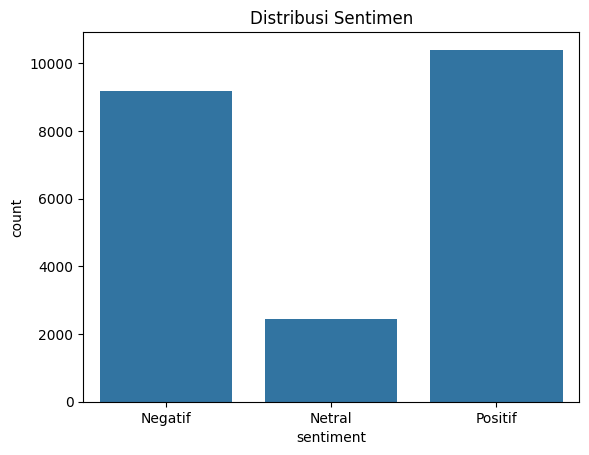

In [29]:
sns.countplot(data=df, x='sentiment') 
plt.title('Distribusi Sentimen') 
plt.show()

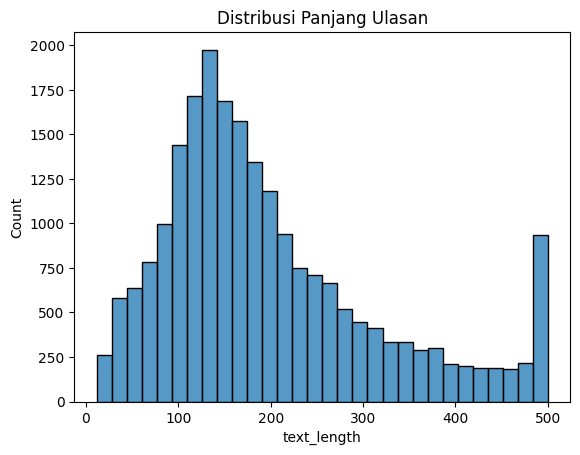

In [30]:
df['text_length'] = df['content'].astype(str).apply(len)
sns.histplot(df['text_length'], bins=30) 
plt.title('Distribusi Panjang Ulasan') 
plt.show()

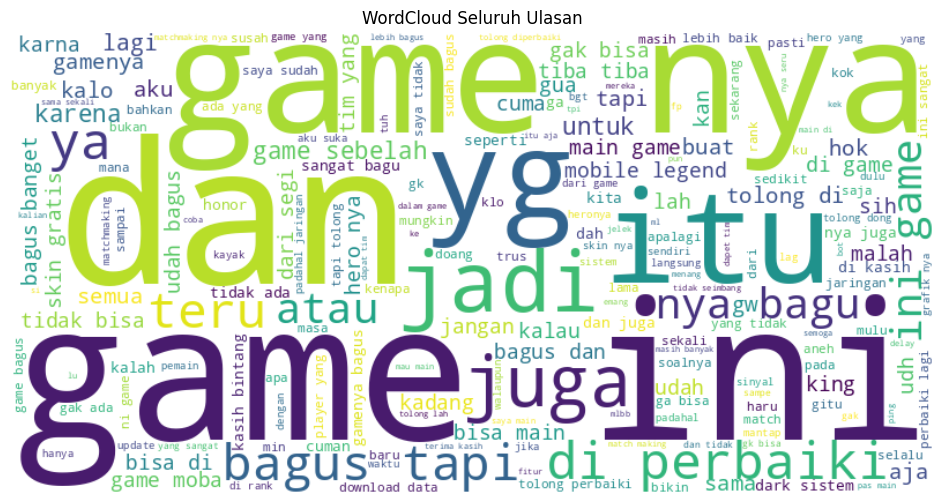

In [31]:
text = ' '.join(df['content'].astype(str)) 
words = text.split()
wordcloud = WordCloud(
    width=800, height=400, background_color='white'
).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Seluruh Ulasan')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [32]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)      # hapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text)      # hapus hashtag
    text = re.sub(r'RT[\s]', '', text)              # hapus RT
    text = re.sub(r"http\S+", '', text)             # hapus link
    text = re.sub(r'[0-9]+', '', text)              # hapus angka
    text = text.replace('\n', ' ')                  
    text = re.sub(r'[^\w\s]', ' ', text)            
    text = re.sub(r'\s+', ' ', text).strip()        
    return text
 
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text
 


slangwords = {"@": "di","gk": "tidak","ga": "tidak","tp":"tapi","jlk":"jelek", "gak": "tidak", "y":"iya","woyyyyy":"halo" , "udh": "sudah","udah": "sudah","dah": "sudah","gw":"aku","gua":"aku" ,"yg":"yang","abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", 'udah': 'sudah','kalo': 'kalau','kayak': 'seperti','gitu': 'begitu','pake': 'pakai','cuman': 'cuma','karna': 'karena','kaya': 'seperti','dah': 'sudah','mulu': 'terus','tau': 'tahu','kek': 'seperti',  'ngelag': 'lag','dapet': 'dapat','bener': 'benar','nih': 'ini','ni': 'ini','klo': 'kalau','sampe': 'sampai','gimana': 'bagaimana',"heronya":"hero","permainan":'main',"bermain":'main',"dikasih":'kasih',"nggak": "tidak","doang": "saja"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
    fixed_text = ' '.join(fixed_words)
    return fixed_text

# Membersihkan teks dan menyimpannya di kolom 'text_clean'
df['text_clean'] = df['content'].apply(cleaningText)
 
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
df['text_casefoldingText'] = df['text_clean'].apply(casefoldingText)
 
# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
df['text_slangwords'] = df['text_casefoldingText'].apply(fix_slangwords)
 








In [33]:
df_bert = df[['text_slangwords', 'sentiment']].copy()
df_bert.to_csv('hok_preprocessing.csv', index=False)